In [1]:
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.integrate as integrate
import matplotlib.ticker as ticker

%load_ext autoreload
%autoreload 2

from GP_code import simulate_population_single, get_mean_trajectory_single, simulate_population_double 
from GP_code import get_mean_trajectory_double, simulate_pulsed_therapy, mean_pulsed_therapy
from GP_code import get_concentration



**Figure 1: Validation of single-type process**\
Here we reproduce results from Figure 1: single-type. This is the net growth rate, expected number of cells, and expected number of cell divisions.

In [2]:
def example_rates_single(t):
    '''Simple function to return birth (l) and death rates (mu)'''
    
    # birth and death rate for single-type process
    # A = 0.05, B = 0.1, theta = 0.1, C = 0.08

    l = 0.05 * np.sin(0.1 * t) + 0.1 # Birth rate
    mu = 0.08 # Death rate constant
    return l, mu

In [3]:
#True value: E[Z(t)]
import scipy.integrate as integrate

def func(t):
    '''Equation (2) page 181: E[Z(t)]
    Function to integrate'''
    return (0.05 * np.sin(0.1 * t) + 0.1) - 0.08

def func_sens(t):
    '''average number of cell divisions before time T.
    Function to integrate. See page 183 of paper'''
    return np.exp(0.05/0.1 + (0.1-0.08)*t - (0.05/0.1)*np.cos(0.1*t)) * (0.05*np.sin(0.1 * t) + 0.1)


def calc_expectation(Z0, func, t):
    '''Integral. Expected population size. Z0 is initial population'''
    value, error = Z0 * np.exp(integrate.quad(func, 0, t))
    return value

def calc_cell_division(func_sens, t):
    '''
    Top right of page 183. Integral of given function.
    '''
    
    value, error = integrate.quad(func_sens, 0, t)
    return value



Fig 1 (a): Net growth rate over time.\
Simply define soem time discretised grid. Solve net rate at each point, store, and then plot.
Dashed line is added to give further clarity to the reader as to dynamics at play.

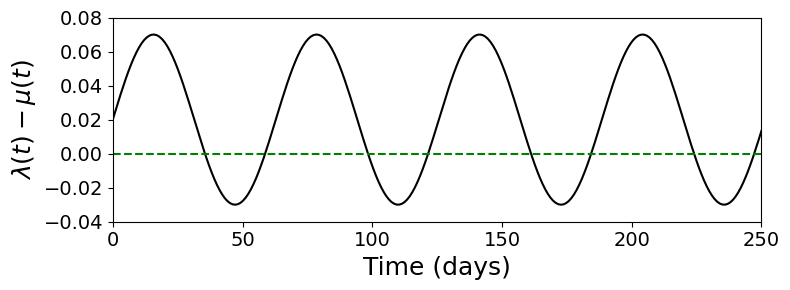

In [ ]:
time = np.linspace(0, 250, 250) # Discretised time grid
y_axis = np.zeros(len(time)) # Intialise array to store rates
y_dashed = np.zeros(len(time)) # Dashed line

# Loop through time and store rates
for i, n in enumerate(time):
    y_axis[i] = func(n)
# Plotting
fig = plt.figure(figsize=(8, 3))

plt.plot(time, y_axis, c = 'black') # Plot results
plt.plot(time, np.zeros(len(time)), '--', c = 'green' ) # Dashed line
# Set axes limits
plt.xlim(0, 250)
plt.ylim(-0.04, 0.08)
# Label axes
plt.xlabel('Time (days)', fontsize=18) 
plt.ylabel(r'$\lambda(t) - \mu(t)$', fontsize=18)

#set tick marks
plt.xticks(np.arange(0, 251, 50), fontsize=14) 
plt.yticks(np.arange(-0.04, 0.081, 0.02), fontsize=14)
# Uncomment to overwrite figure
# Save fig
plt.tight_layout()
#plt.savefig('Figs/single_type_net_growth_rate.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 1(b): E[Y(t)]: Expected number of sensitive cells for a single-type non-homogenous birth-death process

This is the analytical approximation $$E[Z(t)] = Z_0exp[\int_0^t (\lambda (\tau ) - \mu (\tau )) d \tau ]$$
lambda and mu are given in the function example_rates_single as above

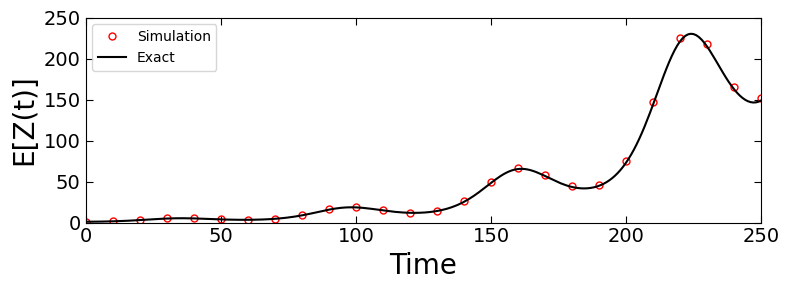

In [ ]:

vals = np.linspace(0, 250, 250)
store = np.zeros(len(vals))
for i, _ in enumerate(vals):
    store[i] = calc_expectation(1, func, _)

#Need 10000+ trials to get an accurate figure. Can take oer 10 minutes
N = 5000 #Number of trials
M = 1

fig = plt.figure(figsize=(8, 3))
grid, mean_pop, mean_divs, var = get_mean_trajectory_single(N, 250, M, example_rates_single, 0.3)
plt.plot(grid, mean_pop, 'o', markevery = 10, markersize = 5, 
         c = 'red', label = f'Simulation', fillstyle = 'none')
plt.plot(vals, store, c = 'black', linestyle = '-', label = 'Exact')
plt.legend()
plt.xlim(0, 250)
plt.ylim(0, 250)

plt.xlabel('Time', fontsize=20)
plt.ylabel('E[Z(t)]', fontsize=20)

#set tick marks
plt.xticks(np.arange(0, 251, 50), fontsize=14) 
plt.yticks(np.arange(0, 251, 50), fontsize=14)

plt.tick_params(axis='both', which='major', 
                top=True, right=True, 
                direction='in', # Optional: points ticks inward
                length=5, # Optional: makes ticks more prominent
                labelsize=14)

plt.tight_layout()

#uncomment to overwrite figure
#plt.savefig('Figs/single_type_population.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 1(c): Number of sensitive cell divisions

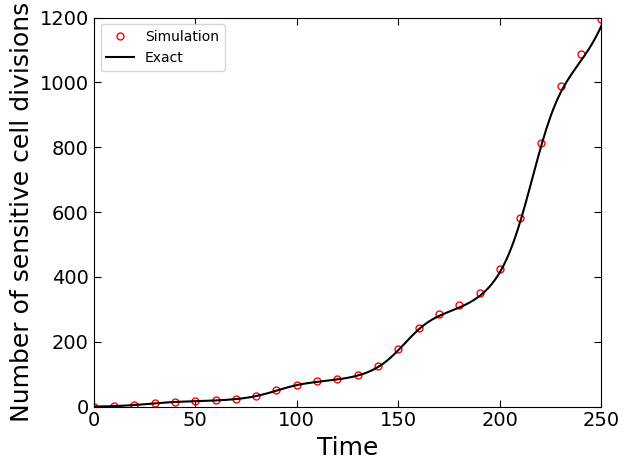

In [ ]:
vals_c = np.linspace(0, 250, 250)
store_c = np.zeros(len(vals_c))
for i, _ in enumerate(vals_c):
    store_c[i] = calc_cell_division(func_sens, _)

#mean_divs is taken from Fig 1(b), therefore, N trials is dependent on above cell
# Could recalculate if you wanted, but this just saves time, especially when N is large
plt.plot(grid, mean_divs,'o', markevery = 10, markersize = 5, fillstyle = 'none', 
         c = 'red', label = f'Simulation' )
plt.plot(vals_c, store_c, c = 'black', linestyle = '-', label = 'Exact')
plt.legend()

plt.xlim(0, 250)
plt.ylim(0, 1200)

plt.xlabel('Time', fontsize=18)
plt.ylabel('Number of sensitive cell divisions', fontsize=18)

#set tick marks
plt.xticks(np.arange(0, 251, 50), fontsize=14) 
plt.yticks(np.arange(0, 1201, 200), fontsize=14)

plt.tick_params(axis='both', which='major', 
                top=True, right=True, 
                direction='in', # Optional: points ticks inward
                length=5, # Optional: makes ticks more prominent
                labelsize=14)

plt.tight_layout()


#uncomment to overwrite figure
#plt.savefig('Figs/single_type_divisions.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 1(extra): Variance

In [4]:
#parameters as per Fig 1a
A = 0.05
theta = 0.1
B = 0.1
C = 0.08
M0 = 1

#function for numerical solution
def example_rates_single(t):
    # Example: rates depend on drug concentration
    l = A * np.sin(theta * t) + B # Birth rate
    mu = C # Death rate increases over time
    return l, mu

#--------------------------------------------------------

#Analytical solution
def lamb(t):
    return A * np.sin(theta * t) + B

def mu(t):
    return C

def w(tau):
    def integrand(eta):
        return  mu(eta) - lamb(eta)
    value, error = integrate.quad(integrand, 0, tau)
    return np.exp(value)

def var_single(t):
    def integrand(tau):
        return (lamb(tau) + mu(tau)) * w(tau)
    value, error = integrate.quad(integrand, 0, t)
    return M0 * w(t)**(-2) * value
        

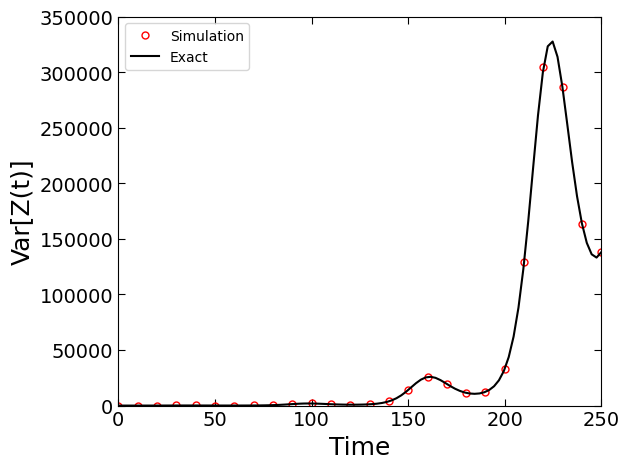

In [ ]:
#N = 5000 #Number of trials. Need a lot for this (~5000)
# T = 250
# beta = 0.7
# N = 10
# M0 = 1

# Var defined above. No need for additional simulations
#grid, mean_pop, mean_r, var = get_mean_trajectory_single(N, T, M0, example_rates_single, beta)
plt.plot(grid, var, 'o', markevery = 10, markersize = 5, fillstyle = 'none', 
         c = 'red', label = f'Simulation' )

vals_v = np.linspace(0, T, 100)
store_v = np.zeros(len(vals_v))
for i, _ in enumerate(vals_v):
    store_v[i] = var_single(_)
plt.plot(vals_v, store_v, c = 'black', linestyle = '-', label = 'Exact')
plt.legend()

plt.xlim(0, 250)
plt.ylim(0, None)

plt.xlabel('Time', fontsize=18)
plt.ylabel('Var[Z(t)]', fontsize=18)

#set tick marks
plt.xticks(np.arange(0, 251, 50), fontsize=14) 
plt.yticks(np.arange(0, 350001, 50000), fontsize=14)

plt.tick_params(axis='both', which='major', 
                top=True, right=True, 
                direction='in', # Optional: points ticks inward
                length=5, # Optional: makes ticks more prominent
                labelsize=14)

plt.tight_layout()


#uncomment to overwrite figure
#plt.savefig('Figs/single_type_variance.pdf', format='pdf', bbox_inches='tight', dpi=300)


plt.show()

Do a P(Z(t)) here **To remove**


In [6]:
def prob_resistance_pulsed(T, M, s, u):
    # 1. P_res_0(T): Probability initial resistant population goes extinct
    def w_initial(tau):
        r = get_rates(tau)
        return r['muy'] - r['ly']
    
    def integrand_res(tau):
        r = get_rates(tau)
        # integral of (mu - l) from 0 to tau
        inner_int, _ = integrate.quad(w_initial, 0, tau)
        return r['muy'] * np.exp(inner_int)
    
    val_res, _ = integrate.quad(integrand_res, 0, T)
    # Z0 = M * s
    p_res_0 = (val_res / (1 + val_res))**(M * s)

Fig 2(a): Expected number of resistant cells

In [5]:
def example_rates_double(t, B1, C2):
    # Example: rates depend on drug concentration
    l_x = 0.05 * np.sin(0.1 * t) + B1 # Birth rate sensitive cells
    l_y = 0.05 * np.sin(0.1 * t) + 0.12 # Birth rate resistant cells
    mu_x = 0.14 # death rate of sensitive cells
    mu_y = C2 # death rate of resistant cells
    return l_x, l_y, mu_x, mu_y

In [6]:
#Define analytical result of expected size of resistant cell population
#l_x = 0.05sin(0.1t)+0.1
#mu_x = 0.14
#l_y = 0.05sin(0.1t)+0.12
#mu_y = [0.09, 0.1, 0.11]
#M = 100
#u = 10**-3

#Using R(t), bottom left page 181

def b_tau(tau):
    term1 = (0.05/0.1) + ((0.1 - 0.14)*tau) - ((0.05/0.1)*np.cos(0.1*tau))
    term2 = (0.05*np.sin(0.1*tau) + 0.1)*1e-3
    return 100 * np.exp(term1)*term2

def R_t(t, C2):
    def integral(tau):
        #b_tau(t)
        term1 = (0.05/0.1)*np.cos(0.1*tau) - (0.05/0.1)*np.cos(0.1*t) + (0.12-C2)*t +(C2-0.12)*tau
        func = b_tau(tau)*np.exp(term1)
        return func
    value, error = integrate.quad(integral, 0, t)
    return value

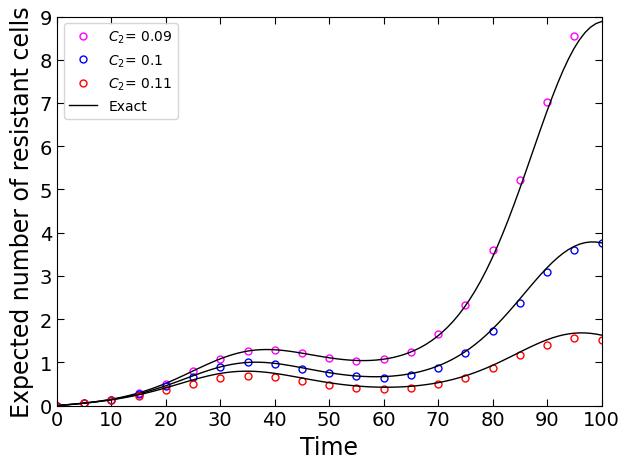

In [ ]:
N = 5000 #Number of trials
T_max = 100
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
B1 = 0.1

c_vals = [0.09, 0.1, 0.11]
colours = ['magenta','blue','red']
_ = zip(c_vals, colours)
count = 0

for C2, color in _:
    grid, mean_pop, mean_r, probs, var_r = get_mean_trajectory_double(N, T_max, M0, R0, example_rates_double, beta, u, B1, C2)
   
    # plt.plot(grid, mean_r, c = 'red', label = f'Numerical solution: {N} trials, C2 = {C2}' )
    plt.plot(grid, mean_r, 'o', c = color, markersize = 5, markevery = 5, fillstyle = 'none', label = r'$C_2$' f'= {C2}' )

    vals_r = np.linspace(0, 100, 100)
    store_r = np.zeros(len(vals_r))

    for i, _ in enumerate(vals_r):
        store_r[i] = R_t(_, C2)

    #Simple counter to only add 'Exact' to the legend once    
    if count == 2:
        plt.plot(vals_r, store_r, c = 'black', linestyle = '-', linewidth=1, label = 'Exact')
    else:
        plt.plot(vals_r, store_r, c = 'black', linestyle = '-', linewidth=1)
    count += 1
plt.legend()
plt.xlim(0, 100)
plt.ylim(0, 9)

plt.xlabel('Time', fontsize=17)
plt.ylabel('Expected number of resistant cells', fontsize=17)

#set tick marks
plt.xticks(np.arange(0, 101, 10), fontsize=14) 
plt.yticks(np.arange(0, 10, 1), fontsize=14)

plt.tick_params(axis='both', which='major', 
                top=True, right=True, 
                direction='in', # Optional: points ticks inward
                length=5, # Optional: makes ticks more prominent
                labelsize=14)

plt.tight_layout()

#uncomment to overwrite figure
#plt.savefig('Figs/double_type_population.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 2(b): Probability of Resistance

In [8]:
#b_tau already defined
#We are looking for P_r(T) = 1- exp(integral(-b + b * P_ext dt)from 0 T)
#define p_ext as Q/1+Q
def b_t(tau):
    term1 = (0.05/0.1) + ((0.1 - 0.14)*tau) - ((0.05/0.1)*np.cos(0.1*tau))
    term2 = (0.05*np.sin(0.1*tau) + 0.1)*1e-3
    return 100 * np.exp(term1)*term2

def P_rt (t, T, B1):
    def P_exp():
        def integral(t, T):
            def Q(tau):
                #b_tau(t)
                term1 = (0.05/0.1)*np.cos(0.1*(tau+t)) - (0.05/0.1)*np.cos(0.1*t) - (0.1)*tau
                func = 0.1*np.exp(term1)
                return func
            value, error = integrate.quad(Q, 0, T-t)
            return value
        p_exp = integral/(1+integral)
        return p_exp
    term = -b_t(t) + (b_t(t) * P_exp)
    value, error = integrate.quad(term, 0, T)
    return 1 - np.exp(value)

In [9]:
M = 100
u = 1e-3
theta = 0.1
A = 0.05
C1 = 0.14
B2, C2 = 0.12, 0.1 

def get_b_t(t, B1):
    exponent = (A/theta) - (A/theta)*np.cos(theta*t) + (B1 - C1)*t
    S_t = M * np.exp(exponent)
    l_x_t = A * np.sin(theta*t) + B1
    return S_t * l_x_t * u

def get_Q(t, T):
    # Q is the integral from 0 to (T-t)
    def Q_integrand(tau):
        q_exp = (A/theta)*np.cos(theta*(t+tau)) - (A/theta)*np.cos(theta*t) - (B2 - C2)*tau
        return C2 * np.exp(q_exp)

    val, _ = integrate.quad(Q_integrand, 0, T - t)
    return val

def get_P_ext(t, T):
    Q_val = get_Q(t, T)
    return Q_val / (1 + Q_val)

def P_R(T, B1):
    # Final integral from 0 to T of [-b(t) + b(t)*P_ext(t,T)]
    def final_integrand(t):
        bt = get_b_t(t, B1)
        pext = get_P_ext(t, T)
        return -bt + (bt * pext)

    integral_val, _ = integrate.quad(final_integrand, 0, T)
    return 1 - np.exp(integral_val)

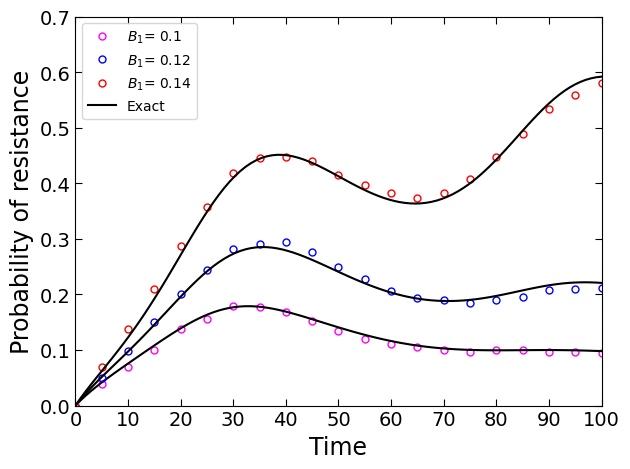

In [ ]:
N = 2500 #Number of trials. Need a lot for this
T_max = 100
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
C2 = 0.1

count = 0
B_ = [0.1, 0.12, 0.14]
colours = ['magenta','blue','red']
_ = zip(B_, colours)
for B1, cols in _ :
    grid, mean_pop, mean_r, probs, var = get_mean_trajectory_double(N, T_max, M0, R0, 
                                                               example_rates_double, beta, u, B1, C2)
    plt.plot(grid, probs, 'o', markersize = 5, markevery = 5, fillstyle = 'none', c = cols, label = r'$B_1$' f'= {B1}' )

    vals_r = np.linspace(0, 100, 100)
    store_r = np.zeros(len(vals_r))
    for i, _ in enumerate(vals_r):
        store_r[i] = P_R(_, B1)
    if count == 2:
        plt.plot(vals_r, store_r, c = 'black', linestyle = '-', label = 'Exact')
    else:
        plt.plot(vals_r, store_r, c = 'black', linestyle = '-')
    count += 1
plt.legend()

plt.xlim(0, 100)
plt.ylim(0, None)

plt.ylabel('Probability of resistance', fontsize = 17)
plt.xlabel('Time', fontsize = 17)

#set tick marks
plt.xticks(np.arange(0, 101, 10), fontsize=14) 
plt.yticks(np.arange(0, 0.8, 0.1), fontsize=14)

plt.tick_params(axis='both', which='major', 
                top=True, right=True, 
                direction='in', # Optional: points ticks inward
                length=5, # Optional: makes ticks more prominent
                labelsize=14)

plt.tight_layout()

#plt.savefig('Figs/double_type_probability.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 2(c): Variance of resistant cell population

In [11]:
#Analytical solution
#need to define lamba_y, w_hat, and b.
#we can use b as per above
A = 0.05
theta = 0.1
B1 = 0.1
B2 = 0.12
C1 = 0.14
C2 = 0.1

M = 100
u = 1e-3


def get_b_t(t):
    # This is b(t): the rate of production of resistant cells at time t
    # Integral of (l_x - mu_x) = (A/y) - (A/y)cos(yt) + (B1-C1)t
    exponent = (A/theta) - (A/theta)*np.cos(theta*t) + (B1 - C1)*t
    S_t = M * np.exp(exponent)
    l_x_t = A * np.sin(theta*t) + B1
    return S_t * l_x_t * u

def lambda_y(z):
    #z = tau + t
    result = A * np.sin(theta * z) + B2
    return result

def w_hat(o, t):
    #o can be tau, T-t, etc.
    def integrand(n):
        return C2 - lambda_y((n+t))
    integ, _ = integrate.quad(integrand, 0, o)
    return np.exp(integ)

def integ_1(t, T):
    #integral within variance integral
    #integral of w(tau, t) * lambdaY(tau + t) dtau from 0 to T-t
    def integrand(tau):
        z = tau + t
        term = w_hat(tau, t) * lambda_y(z)
        return term
    value, _ = integrate.quad(integrand, 0, (T-t))
    return value

def var_R(T):
    #Variance of population of resistance cells
    def integrand(t):
        o = T-t
        w = w_hat(o, t)
        numerator = get_b_t(t) * (w + (2 * integ_1(t, T)))
        denominator = w**2
        full = numerator / denominator
        return full
    value, _ = integrate.quad(integrand, 0, T)
    return value

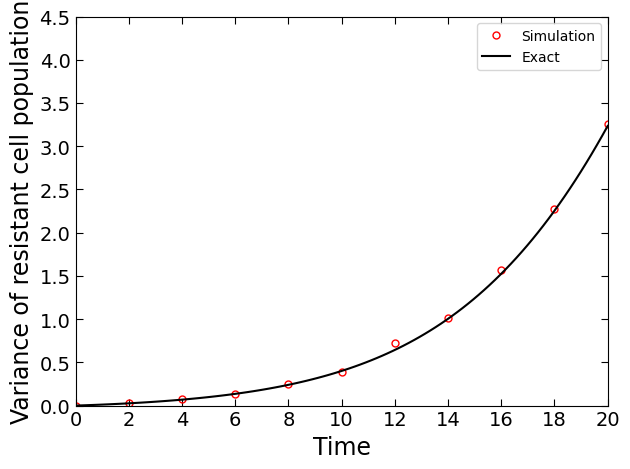

In [ ]:
N = 5000 #Number of trials. Need a lot for this (~5000)
T = 20
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
C2 = 0.1
B1 = 0.1
grid, mean_pop, mean_r, probs, var = get_mean_trajectory_double(N, T, M0, R0, 
                                                            example_rates_double, beta, u, B1, C2)
plt.plot(grid, var, 'o', c = 'red', markevery = 2, markersize = 5, fillstyle = 'none', label = f'Simulation' )

vals_v = np.linspace(0, T, 100)
store_v = np.zeros(len(vals_v))
for i, _ in enumerate(vals_v):
    store_v[i] = var_R(_)
plt.plot(vals_v, store_v, c = 'black', linestyle = '-', label = 'Exact')
plt.legend()

plt.xlim(0, 20)
plt.ylim(0, 4.5)

plt.ylabel('Variance of resistant cell population', fontsize=17)
plt.xlabel('Time', fontsize=17)

#set tick marks
plt.xticks(np.arange(0, 21, 2), fontsize=14) 
plt.yticks(np.arange(0, 4.6, 0.5), fontsize=14)

plt.tick_params(axis='both', which='major', 
                top=True, right=True, 
                direction='in', # Optional: points ticks inward
                length=5, # Optional: makes ticks more prominent
                labelsize=14)

plt.tight_layout()


#plt.savefig('Figs/double_type_variance.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

For large N i can match analytical result, so I don't think the issue is on my side. var at T = 20 should be ~ 4, but I get ~3.2. Could be parameter issue, need to check these. Maybe find a more general way to do it

In [55]:
#----------------------------

Look at single type Var, as Ruby \& Janet noticed issues

In [58]:
#Analytical solution for single-type as per paper

**Var[Z(t)]**
The paper has definitley made a mistake. Ruby has derived the correct analytical solution, which perfectly matches the numerical solution, (which I have faith in).
Need to track the process. I originally tried the papers solution. Staggering difference. \
Give the net positive rate, the variance should be large. The issue is that they should have excluded the exponential in w(t) or included it, but removed from the final; equation. \
Can show that we also checked the approximate variance and showed that it should be large. 

Fig 3: Pre-existanxce \
We are looking at the expected number of resistant cells and the probability of resistance, given a pre-exisiting population R. \
\
s should be easy to include where the pre existing population S(0) = M(1-s) and R(0) = Ms. \
We have a 14 day on/off dosing schedule.

In [10]:
#define rates for this example. See function simulate_pulsed_therapy for definition and explanation
rates = {
        'on':  {'lx': 0.05, 'ly': 0.11, 'mux': 0.1, 'muy': 0.1},
        'off': {'lx': 0.13, 'ly': 0.15, 'mux': 0.1, 'muy': 0.1}
    }

#t , s, r = simulate_pulsed_therapy(rates, T_max, M0, beta, u, cycle_length, dosing_length, s)

Fig 3.a: Expected number of resistant cells for some pre-existing resistant poplation, for a dosing schedule
Analytical missing, circles look good though

In [11]:
#Define analytical solutions
#R(T) = R_sens(T) + R_res(T)
#R_sens(T) eq(7), already used
#update params. Use M(1-s)

def get_rates(t):
    # 14 days on (0-14), 14 days off (14-28)
    phase = 'on' if (t % 28) < 14 else 'off'
    return rates[phase]


# def b_pulsed(t, M, s, u):
#     r = get_rates(t)
    
#     # We need the integral of (lx - ux) from 0 to t
#     # For pulsed schedules, quad is still the easiest way to handle the step function
#     def net_growth_s(tau):
#         rt = get_rates(tau)
#         return rt['lx'] - rt['mux']
    
#     integral_val, _ = integrate.quad(net_growth_s, 0, t)
#     return (M*(1-s)) * np.exp(integral_val) * r['lx'] * u

def R_t_pulsed(t, M, s, u):
    # 1. Calculate R_res(T): Growth of cells already resistant at t=0
    def net_growth_r(tau):
        r = get_rates(tau)
        return r['ly'] - r['muy']
    
    # Growth of the initial M*s population
    integral_r_total, _ = integrate.quad(net_growth_r, 0, t)
    r_res = (M * s) * np.exp(integral_r_total)

    # 2. Calculate R_sens(T): Cells transitioning from Sensitive to Resistant
    def integrand(tau):
        # Calculate b(tau)
        def net_growth_s(eta):
            r = get_rates(eta)
            return r['lx'] - r['mux']
        
        int_s, _ = integrate.quad(net_growth_s, 0, tau)
        r_tau = get_rates(tau)
        b_tau = (M * (1 - s)) * np.exp(int_s) * r_tau['lx'] * u
        
        # Calculate the expansion of those cells from tau to t
        int_r_suffix, _ = integrate.quad(net_growth_r, tau, t)
        return b_tau * np.exp(int_r_suffix)

    r_sens, _ = integrate.quad(integrand, 0, t)
    
    return r_sens + r_res




C:\Users\Colm\AppData\Local\Temp\ipykernel_2604\2093693093.py:49: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  r_sens, _ = integrate.quad(integrand, 0, t)
C:\Users\Colm\AppData\Local\Temp\ipykernel_2604\2093693093.py:41: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and callin

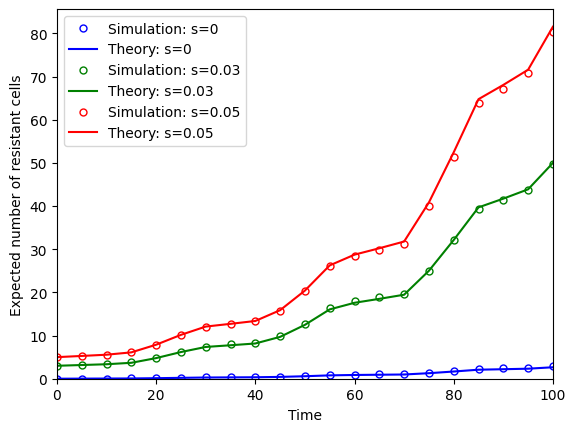

In [ ]:
T_max = 100
M0 = 100 # Not specified, this is an assumption
beta = 0.5
u = 1e-3
cycle = 28
dosing = 14
N = 2000

time = np.linspace(0, 100, 21)


freq = [0, 0.03, 0.05]
colours = ['blue', 'green', 'red']
g = zip(freq, colours)

for s, cols in g:
    store = np.zeros(len(time))
    grid, pop_s, pop_r, prob_r, var_r = mean_pulsed_therapy(N, T_max, M0, rates, beta, u, cycle, dosing, s)
    plt.plot(grid, pop_r, 'o', c = cols, label = f'Simulation: s={s}',
             markevery = 5, markersize = 5, fillstyle = 'none')
    for i, x in enumerate(time):
        store[i] = R_t_pulsed(x, M0, s, u)
    plt.plot(time, store, '-', c = cols, label = f'Theory: s={s}')

plt.ylabel('Expected number of resistant cells')
plt.xlabel('Time')

plt.xlim(0, T_max)
plt.ylim(0, None)
plt.legend()
plt.savefig('Figs/pulsed_population.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

Fig 3.b: Probability of Resistance given some pre-existing resistant cell population for some dosing schedule

In [ ]:
#Analytical solution
#P_R(T) = 1-P_0(T) = 1 - P_sens(T)*P_res(T)

#P_sens(T) = equation 10
# P_ext = equation 8
# w_hat = equation 9

This is the general solution of probability of resistance for pre-existing resistance. This is very computationally expensive

In [12]:
def get_w_hat(t_start, t_end):
    """Calculates w_hat(t, tau) where tau is the duration (t_end - t_start)"""
    def integrand(Z):
        # Rates at Z + t_start
        r = get_rates(Z + t_start)
        return r['muy'] - r['ly']
    
    val, _ = integrate.quad(integrand, 0, t_end - t_start)
    return np.exp(val)

def get_Pext(t, T):
    """Equation 8: Probability of extinction of a lineage born at time t by time T"""
    if t >= T: return 1.0
    
    def integrand(tau):
        # Rate at tau + t
        r = get_rates(tau + t)
        # w_hat(t, tau)
        return r['muy'] * get_w_hat(t, tau + t)
    
    num, _ = integrate.quad(integrand, 0, T - t)
    return num / (1 + num)

def prob_resistance_pulsed(T, M, s, u):
    # 1. P_res_0(T): Probability initial resistant population goes extinct
    def w_initial(tau):
        r = get_rates(tau)
        return r['muy'] - r['ly']
    
    def integrand_res(tau):
        r = get_rates(tau)
        # integral of (mu - l) from 0 to tau
        inner_int, _ = integrate.quad(w_initial, 0, tau)
        return r['muy'] * np.exp(inner_int)
    
    val_res, _ = integrate.quad(integrand_res, 0, T)
    # Z0 = M * s
    p_res_0 = (val_res / (1 + val_res))**(M * s)

    # 2. P_sens_0(T): Probability all mutated lineages go extinct
    def integrand_sens(t):
        # b(t) calculation (Birth rate of mutants)
        def net_growth_s(tau):
            r = get_rates(tau)
            return r['lx'] - r['mux']
        
        int_s, _ = integrate.quad(net_growth_s, 0, t)
        r_t = get_rates(t)
        b_t = (M * (1 - s)) * np.exp(int_s) * r_t['lx'] * u
        
        # Pext(t, T)
        p_ext = get_Pext(t, T)
        return b_t * (1 - p_ext)

    val_sens, _ = integrate.quad(integrand_sens, 0, T)
    p_sens_0 = np.exp(-val_sens)

    # Total Probability of Resistance = 1 - (P_sens_0 * P_res_0)
    return 1 - (p_sens_0 * p_res_0)

In [8]:
prob_resistance_pulsed(10, 100, 0, 1e-3)

np.float64(0.02639307423883619)

This is an updated version which pre calculates integrals x and y to avoid O(N^3) comp cost

In [15]:
import numpy as np
from scipy.integrate import quad, solve_ivp
from scipy.interpolate import interp1d


from scipy import integrate

# Parameters from Figure 3/4.3 [cite: 156, 140]
M = 100
u = 1e-3
cycle = 28
dosing = 14

# Rates 
# Sensitive (X): lambda_on=0.05, lambda_off=0.13, mu=0.1
# Resistant (Y): lambda_on=0.11, lambda_off=0.15, mu=0.1
rates_x = {'on': 0.05 - 0.1, 'off': 0.13 - 0.1}
rates_y = {'on': 0.11 - 0.1, 'off': 0.15 - 0.1}

def get_integrated_growth(t_start, t_end, rates):
    """Algebraic integral of (lambda - mu). Used for b(t)."""
    def integral_from_zero(t):
        num_cycles = t // 28
        remainder = t % 28
        on_time = num_cycles * 14 + min(remainder, 14)
        off_time = t - on_time
        return (on_time * rates['on']) + (off_time * rates['off'])
    return integral_from_zero(t_end) - integral_from_zero(t_start)

def precompute_extinction_prob(T_max, rates_y):
    """
    Solves the Riccati ODE for extinction probability backwards from T_max.
    dP/dt = - [mu*(1-P)^2 - (mu-lambda)*(1-P)]
    """
    def ode_func(t, P):
        # We need the rates at time t
        phase = 'on' if (t % 28) < 14 else 'off'
        # Note: rates_y['on'] is (lambda - mu), so we extract lambda and mu
        # Assuming mu is constant 0.1 as per your 'rates' dict
        muy = 0.1 
        ly = rates_y[phase] + muy 
        return -(muy * (1 - P)**2 - (muy - ly) * (1 - P))

    # Solve backwards from T to 0
    sol = solve_ivp(ode_func, (T_max, 0), [1.0], t_eval=np.linspace(T_max, 0, 200))
    # Returns a function that gives P_ext(t)
    return interp1d(sol.t[::-1], sol.y[0][::-1], kind='cubic')

def prob_resistance_pulsed(T, M, s, u, p_ext_func):
    # 1. P_res: Initial resistant cells extinction
    # For pulsed, the paper uses the integral of mu*w
    def integrand_res(tau):
        phase = 'on' if (tau % 28) < 14 else 'off'
        muy = 0.1
        # Integral of (mu - lambda) from 0 to tau
        # This is just -1 * integrated_growth
        val = -get_integrated_growth(0, tau, rates_y)
        return muy * np.exp(val)
    
    integral_res, _ = quad(integrand_res, 0, T)
    p_res_0 = (integral_res / (1 + integral_res))**(M * s)

    # 2. P_sens: Mutations extinction
    def integrand_sens(t):
        # Growth of sensitive cells to calculate mutation rate b(t)
        growth_x = get_integrated_growth(0, t, rates_x)
        birth_x = 0.05 if (t % 28) < 14 else 0.13
        b_t = M * (1 - s) * np.exp(growth_x) * birth_x * u
        
        # 1 - P_ext(t, T) is the probability the lineage SURVIVES
        return b_t * (1 - p_ext_func(t))

    integral_sens, _ = quad(integrand_sens, 0, T)
    p_sens_0 = np.exp(-integral_sens)
    

    return 1 - (p_sens_0 * p_res_0)



In [25]:
p_ext_lookup = precompute_extinction_prob(100, rates_y)
p_ext_lookup
# s, r = prob_resistance_pulsed(100, 100, 0, 1e-3, p_ext_lookup)
# s, r

C:\Users\Colm\AppData\Local\Temp\ipykernel_21600\1342258125.py:60: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_res, _ = quad(integrand_res, 0, T)


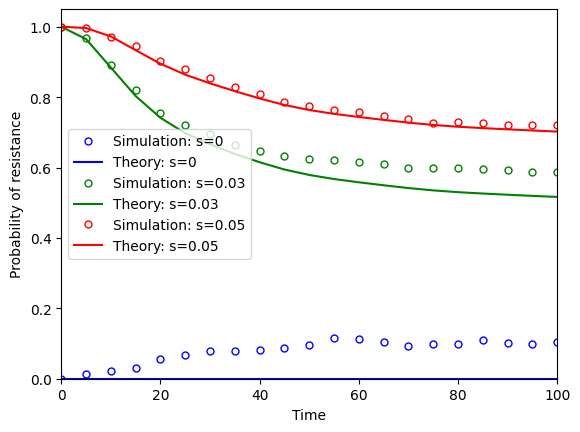

In [19]:
T_max = 100
M0 = 100 # Not specified, this is an assumption
beta = 0.5
u = 1e-3
cycle = 28
dosing = 14
s = 0.03
N = 1000

p_ext_lookup = precompute_extinction_prob(100, rates_y)

frequencies = [0, 0.03, 0.05]
colours = ['blue', 'green', 'red']
g = zip(frequencies, colours)

time = np.linspace(0, 100, 21)

for s, cul in g:
    store = np.zeros(len(time))
    grid, pop_s, pop_r, prob_r, var_r = mean_pulsed_therapy(N, T_max, M0, rates, beta, u, cycle, dosing, s)
    plt.plot(grid, prob_r,'o', c = cul, label = f'Simulation: s={s}',
              markevery = 5, fillstyle = 'none', markersize = 5 )
    
    for i, x in enumerate(time):
        store[i] = prob_resistance_pulsed(x, M0, s, u, p_ext_lookup)
    plt.plot(time, store, '-', c = cul, label = f'Theory: s={s}')

#xlim and ylim let us cut the axis rather than have padding on either side. Looks better
plt.xlim(0, T_max)
plt.ylim(0, None)

plt.xlabel('Time')
plt.ylabel('Probability of resistance')

plt.legend()
plt.savefig('Figs/pulsed_probability.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Section 4.4: Effect of drug accumulation on the evolution of resistance 

Concentration over time after one dose is given below as C, where D is the daily drug of the dose in some arbitrary unit. k is the rat eof drug elimination

Fig 4.a: Drug concentration, lambda_x, lambda_y as a function of time


In [10]:
D = 0.6 #maintenance dose
tau = 1 #spacing interval
k = 0.2 #decay rate
load = D / (1 - np.exp(-k * tau)) #loading dose
M0 = 1e6 #initial sensitive cell population
u = 1e-8 #mutation rate

In [9]:
#Plot concentration
def concentration(D, k, t):
    return D * np.exp(-k*t)

In [22]:
T = 30
tau = 1
N = T/tau
#time = np.linspace(0, T, N)
def get_concentration(t, D, kappa, tau, loading_dose = False):
    n = int(t / tau) + 1  # Current dose number
    time_since_last = t % tau
    if loading_dose == False:
        D_load = D
    else:
        D_load = D / (1-np.exp(-kappa*tau))
    if n == 1:
        # We are in the first interval; only the loading dose exists
        c_peak = D_load
    else:
        # n-th peak = (Residual of D_load) + (Accumulation of n-1 maint doses)
        # Note: the loading dose has decayed for (n-1) intervals
        term1 = D_load * np.exp(-(n-1) * kappa * tau)
        
        # The maintenance doses have accumulated for (n-1) steps
        term2 = D * (1 - np.exp(-(n-1) * kappa * tau)) / (1 - np.exp(-kappa * tau))
        
        c_peak = term1 + term2
        
    return c_peak * np.exp(-kappa * time_since_last)




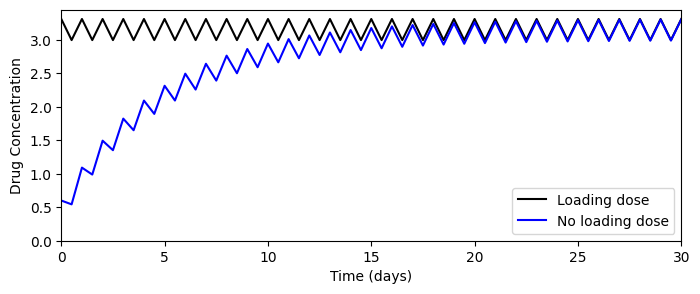

In [14]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_LD = np.zeros(len(time))
store_NLD = np.zeros(len(time))

D = 0.6
k = 0.2
tau = 1

fig = plt.figure(figsize=(8, 3))
for i, g in enumerate(time):
    store_LD[i] = get_concentration(g, D, k, tau, True)
    store_NLD[i] = get_concentration(g, D, k, tau, False)
plt.plot(time, store_LD, c = 'black', label  ='Loading dose')
plt.plot(time, store_NLD, c = 'blue', label = 'No loading dose')
plt.legend()

plt.xlim(0, T)
plt.ylim(0, None)

plt.xlabel('Time (days)')
plt.ylabel('Drug Concentration')

plt.savefig('Figs/drug_concentration_4.pdf', format='pdf', bbox_inches='tight', dpi=300)


plt.show()




In [23]:


def lamb_x(lx, t, D, k, tau, c_max, loading_dose = False):
    #get_concentration(0, D, k, tau, True) + get_concentration(0, D, k, tau, False)
    c = get_concentration(t, D, k, tau, loading_dose)
    rate = lx * (c_max - c)
    return rate, c


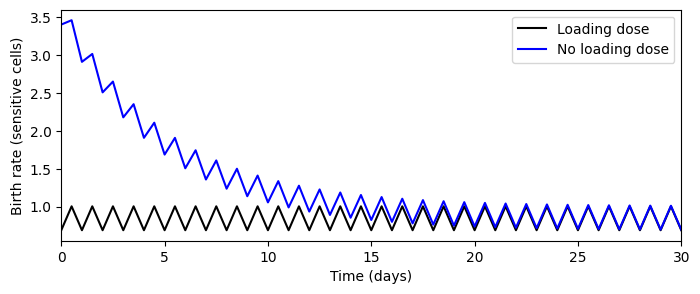

In [16]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_LD = np.zeros(len(time))
store_NLD = np.zeros(len(time))

D = 0.6
k = 0.2
tau = 1

M0 = 1e6
u = 1e-8

lx = 0.1

fig = plt.figure(figsize=(8, 3))

for i, g in enumerate(time):
    rate, _ = lamb_x(lx, g, D, k, tau, 4, True)
    store_LD[i] = rate *M0 *u
    rate_, _ = lamb_x(lx,g, D, k, tau, 4, False)
    store_NLD[i] = rate_ *M0 *u
plt.plot(time, store_LD *1e3, c = 'black', label  ='Loading dose')
plt.plot(time, store_NLD *1e3, c = 'blue', label = 'No loading dose')
plt.legend()
plt.xlim(0, T)
plt.ylim(None, None)

plt.xlabel('Time (days)')
plt.ylabel('Birth rate (sensitive cells)')

plt.savefig('Figs/sens_birth_4.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

This section seems very poorly explained and took a lot of trial and error to figure out. \
Above is the birth rate of resistant cells from a sensitive cell population. \
The rat eis the per-capita rate times the mutation rate.\
The percapita rate is the rate times the population \
rate is birth rate times the accumulated drug. This is done as c_max - current accumulated concentration. This means that, with a loading dose for example, the birth rate is lower. The drug should lower the birth of resistant cells. As the drug accumulates the rate lowers. The steady state remaimns the same, with a sawtooth pattern.

In [24]:
def lamb_y(t, D, k, tau, loading_dose = False):
    ly = 0.0775 #A bit lower given lower fitness cost
    c_max = get_concentration(0, D, k, tau, True) + get_concentration(0, D, k, tau, False)
    #lx = A * np.sin(theta * t) + B1
    rate = ly * (c_max - (0.1 * get_concentration(t, D, k, tau, loading_dose))) #scale given partial resistance to the drug 
    return rate

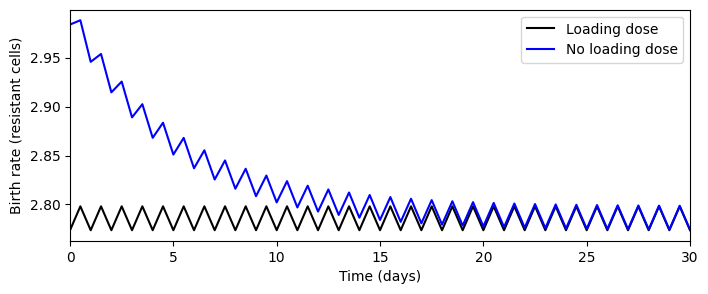

In [20]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_LD = np.zeros(len(time))
store_NLD = np.zeros(len(time))

D = 0.6
k = 0.2
tau = 1

M0 = 1e6
u = 1e-8

fig = plt.figure(figsize=(8, 3))

for i, g in enumerate(time):
    store_LD[i] = lamb_y(g, D, k, tau, True) * M0 * u
    store_NLD[i] = lamb_y(g, D, k, tau, False) * M0 * u
plt.plot(time, store_LD *1e3, c = 'black', label  ='Loading dose')
plt.plot(time, store_NLD * 1e3, c = 'blue', label = 'No loading dose')
plt.legend()
plt.xlim(0, T)
plt.ylim(None, None)

plt.xlabel('Time (days)')
plt.ylabel('Birth rate (resistant cells)')

plt.savefig('Figs/res_birth_rate_4.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

Fig 4b: Show how rates change with drug concentration

If we use our system, there is some beginning dose. So we can never really have 0 units with out system, even at t=0, there'd still be a doseage. So I've set up a new system, that is simplistic, but shows the evolution of the rates

Maybe I should just add a counter the the sawtooth approach above

In [25]:
#def a function of birth & death rates
def rates_conc(lx, ly, mux, muy, c_max, units, a):
    '''
    Input is constant rates.
    For this model assume constant birth and death rates.
    Death rates are unaffected by drug concentration
    birth rate is affected by drug concentration

    lx, ly, mux, muy are constant birth and death rate sof sensitive and resistant cells
    c_max is max possible drug accumulation/concentration which will completely offset the baseline rate
    units is input units of drug concentration(arbitrary)
    a is scaling factor
    '''
    
    l_x = lx * ((c_max - units) / c_max)
    l_y = ly * ((c_max - (a * units)) / c_max)
    mu_x = mux
    mu_y = muy


    return l_x, l_y, mu_x, mu_y


In [40]:
conc = np.linspace(0, 20, 21)
lx, ly, mx, my =  [np.zeros(len(conc)) for i in range(4)]

for i, x in enumerate(conc):
    lx[i], ly[i], mx[i], my[i] = rates_conc(0.4, 0.3, 0.13, 0.2, 4, x, 0.134)

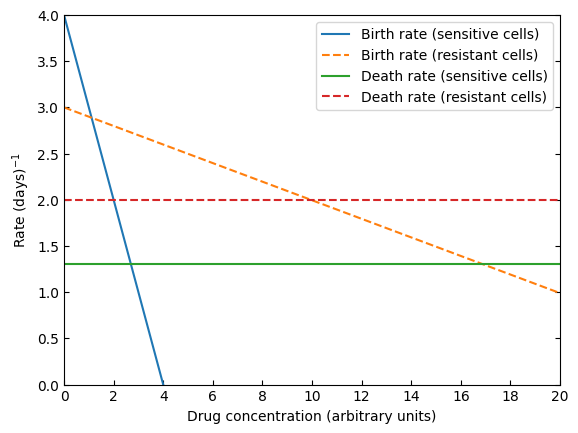

In [41]:
M0 = 1e6
u = 1e-8
plt.plot(conc, lx * M0 * u * 1e3, label = 'Birth rate (sensitive cells)')
plt.plot(conc, ly * M0 * u * 1e3, label = 'Birth rate (resistant cells)', linestyle = '--')
plt.plot(conc, mx * M0 * u * 1e3, label = 'Death rate (sensitive cells)')
plt.plot(conc, my * M0 * u * 1e3, label = 'Death rate (resistant cells)', linestyle = '--')

plt.xlim(0, 20)
plt.ylim(0, 4)
plt.ylabel(r'Rate (days)$^{-1}$')
plt.xlabel('Drug concentration (arbitrary units)')

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))

plt.legend()
plt.gca().tick_params(right=True, direction='in')

plt.savefig('Figs/all_rates_4.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

Fig 4.c Probability of resistance with and without a loading dose. \
Should use analytical P_R(T, B1) \
I'm struggling big time with this

In [100]:
import numpy as np
from scipy.integrate import quad

# --- User-Defined Constants and Functions ---
M = 1e6        # Initial sensitive cells
u = 1e-8       # Mutation rate
g = 0.4      # Resistant cell birth rate constant    # Half-life rate
z = 1 
D = 0.725
kappa = 0.2       # Dosing interval

def C(t):
    """Drug concentration after a single dose at time t."""
    # Example for exponential decay: D * exp(-kappa * t)

    return D*np.exp(-kappa * t)

def birth_X(t):
    C_current =  get_concentration(t, D, kappa = 0.2, tau = 1, loading_dose=False)
    C_max = 4
    return 0.4 *(1- (C_current/C_max)) 


#def birth_X(t): return 0.4 * get_concentration(t, D = 0.6, kappa = 0.2, tau = 1, loading_dose=False)# lambda_X(t)
def death_X(t): return 0.13 # mu_X(t)
def death_Y(t): return 0.2 # mu_Y(t)

#a = get_concentration(g, D, k, tau, False)

# --- Your Pre-solved w_hat ---
def w_hat(tau, t):
    """
    User's simplified/solved w_hat(t, tau).
    Based on your description: exp(mu_y*tau - g*C(t)*(1 - (exp(-kappa*z)/kappa)))
    """
    # Replace the following logic with your exact analytic expression
    val = death_Y(t) * tau - g * C(t) * (1 - (np.exp(-kappa * z) / kappa))
    return np.exp(val)

# --- Equation 6: Resistant cell production rate b(t) ---
def b(t):
    # This involves the sensitive cell growth integral
    growth_integral, _ = quad(lambda tau: birth_X(tau) - death_X(tau), 0, t)
    return M * np.exp(growth_integral) * birth_X(t) * u

# --- Equation 8: Extinction Probability P_ext(t, T) ---
def P_ext(t, T):
    if t >= T:
        return 1.0
    
    # Calculate Q using your analytic w_hat
    # Q = integral from 0 to T-t of mu_Y(tau+t) * w_hat(tau, t)
    Q, _ = quad(lambda tau: death_Y(tau + t) * w_hat(tau, t), 0, T - t)
    
    return Q / (1 + Q)

# --- Equation 11: Probability of Resistance P_R(T) ---
def P_R(T):
    # This is the outer integral: integral from 0 to T of b(t)*(1 - P_ext)
    def integrand(t):
        return b(t) * (1 - P_ext(t, T))
    
    exponent_val, _ = quad(integrand, 0, T)
    return 1 - np.exp(-exponent_val)

# Example usage
T_end = 100
b = P_R(T_end)

C:\Users\Colm\AppData\Local\Temp\ipykernel_21600\2756771650.py:43: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  growth_integral, _ = quad(lambda tau: birth_X(tau) - death_X(tau), 0, t)
C:\Users\Colm\AppData\Local\Temp\ipykernel_21600\2756771650.py:43: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  growth_integral, _ = quad(lambda tau: birth_X(tau) - death_X(tau), 0, t)
C:\Users\Colm\AppData\Local\Temp\ipykernel_21600\2756771650.py:63: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no

In [101]:
b

np.float64(1.7380690094936924e-06)

In [82]:
get_concentration(1000, D = 0.725, kappa = 0.2, tau = 1, loading_dose=False)

np.float64(3.99957528544207)

In [93]:
def birth_X(t):
    C =  get_concentration(t, D = 0.725, kappa = 0.2, tau = 1, loading_dose=False)
    C_max = 4
    return 0.4 *(1- (C/C_max)) 

birth_X(100)

np.float64(4.2472130733228756e-05)

<function matplotlib.pyplot.show(close=None, block=None)>

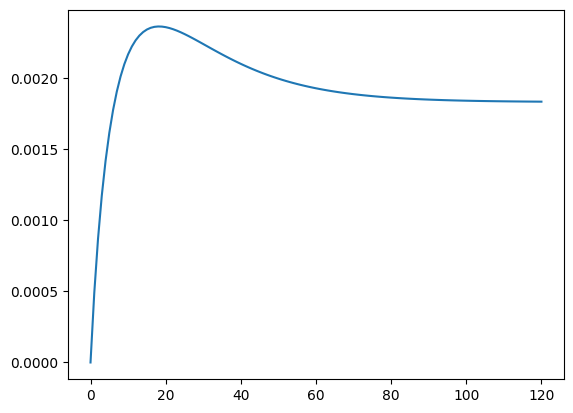

In [111]:
T = 120
M = 1e6
u = 1e-8
kappa = 0.2
loading_dose = True
tau = 1
D = 0.6

time_grid = np.linspace(0, 120, 2401)

time = np.linspace(0, 120, 121)
store = np.zeros(len(time))
for e, g in enumerate(time):
    c_t = np.array([get_concentration(t, D, kappa, tau, loading_dose) for t in time_grid])
    lx_t, ly_t, mux_t, muy_t = rates_conc(0.4, 0.3, 0.13, 0.2, 3.5, c_t, 0.13)
    store[e] = calculate_Pr_at_T(g, M, u, lx_t, mux_t, ly_t, muy_t, time_grid)

plt.plot(time, store)
plt.show

In [105]:
c_t = np.array([get_concentration(t, D, kappa, tau, loading_dose) for t in time_grid])
lx_t, ly_t, mux_t, muy_t = rates_conc(0.4, 0.3, 0.2, 0.2, 4, c_t, 0.5)
ly_t[2400]

np.float64(0.1758752497659791)

Fig 5.a

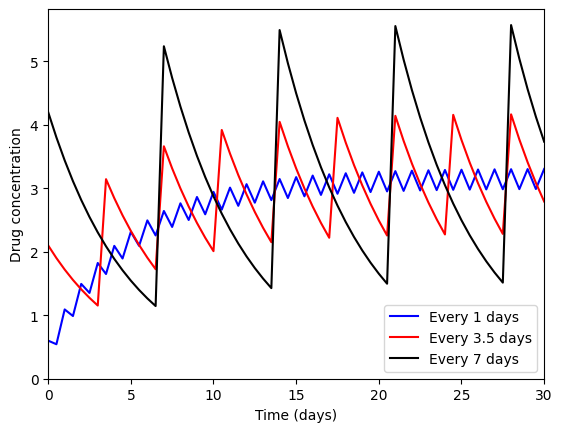

In [21]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_NLD = np.zeros(len(time))

D = 0.6
k = 0.2
tau = [1, 3.5, 7]
colours = ['blue', 'red', 'black']
#To maintain the AUC we need D_new = D_1 * tau_new/tau_1
#tau_1 = 1 so just 0.6 * tau_new
#see notes for derivation. Solve AUC = integral(C(t)) form o to inf
D = 0.6
dict = zip(tau, colours)
for t, col in dict:
    for i, g in enumerate(time):
        store_NLD[i] = get_concentration(g, (D*t), k, t, False)
    plt.plot(time, store_NLD, c = col, label = f'Every {t} days')
plt.legend()
plt.xlim(0, T)
plt.ylim(0, None)

plt.xlabel('Time (days)')
plt.ylabel('Drug concentration')

plt.savefig('Figs/conc_5.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Fig 5.b Probability of resistance for varying frequencies as above. Dno how to do this

In [ ]:
#Try to plot 

In [ ]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

def calculate_Pr_at_T(T, M, u, lx, mux, ly, muy, time_grid):
    # 1. Precompute growth and extinction integrals
    # Net growth integral for sensitive cells
    Vx = np.insert(cumulative_trapezoid(lx - mux, time_grid), 0, 0)
    # Extinction helper integral for resistant cells
    Wy = np.insert(cumulative_trapezoid(muy - ly, time_grid), 0, 0)
    
    # 2. Vectorized b(t)
    b_t = M * np.exp(Vx) * lx * u
    
    # 3. Vectorized Q(t, T) for a specific T
    # Q(t, T) = exp(-Wy(t)) * [Integral from t to T of (muy * exp(Wy))]
    f_tau = muy * np.exp(Wy)
    integral_f = np.insert(cumulative_trapezoid(f_tau, time_grid), 0, 0)
    
    # Find the index for T
    T_idx = np.searchsorted(time_grid, T)
    
    # For all t up to T, calculate Q(t, T)
    # integral_t_to_T = integral_0_to_T - integral_0_to_t
    Q_t_T = (1.0 / np.exp(Wy[:T_idx+1])) * (integral_f[T_idx] - integral_f[:T_idx+1])
    P_ext_t_T = Q_t_T / (1.0 + Q_t_T)
    
    # 4. Calculate Final Probability of Resistance (Eq 11)
    # Pr(T) = 1 - exp( - integral of b(t) * (1 - Pext) )
    integrand = b_t[:T_idx+1] * (1.0 - P_ext_t_T)
    val_sens = np.trapezoid(integrand, time_grid[:T_idx+1])
    
    return 1 - np.exp(-val_sens)

Fig 6.a

This plot is to simply show the relationship between the administed frequency and the tolerated dose. We use an exponential decay. $$g(x) = a \cdot \exp ^{-b}$$

In [18]:
def g_x(a, x):

    g_x = a * np.exp(-0.3 * x)
    return g_x

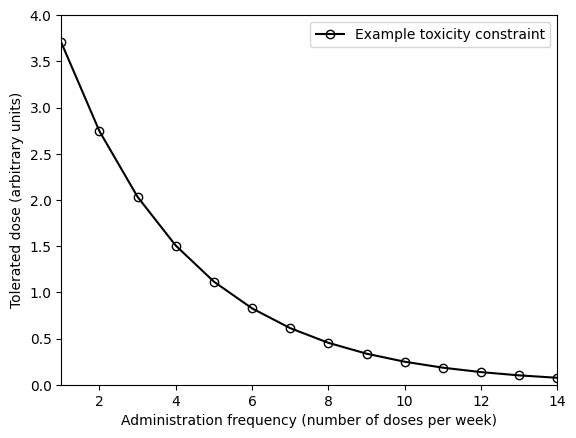

In [35]:
frequency = np.linspace(1, 14, 14)
results = np.zeros(len(frequency))

for i, x in enumerate(frequency):
    results[i] = g_x(5, x)

plt.plot(frequency, results, label = 'Example toxicity constraint', marker = 'o', fillstyle = 'none', c = 'black')
plt.legend()
plt.xlim(1, 14)
plt.ylim(0, 4)
plt.ylabel('Tolerated dose (arbitrary units)')
plt.xlabel('Administration frequency (number of doses per week)')

plt.savefig('Figs/gx_6.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()



Fig 6.b: Rate Vs Drug concentration. 

In [3]:
conc = np.linspace(0, 10, 11)
lx, ly, mx, my =  [np.zeros(len(conc)) for i in range(4)]

for i, x in enumerate(conc):
    lx[i], ly[i], mx[i], my[i] = rates_conc(0.4, 0.3, 0.2, 0.2, 2.5, x, 0.08)

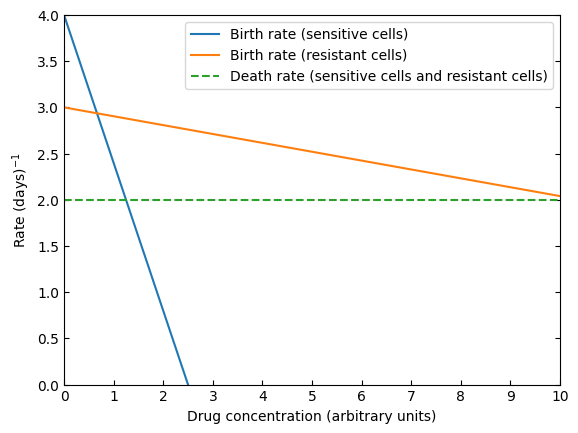

In [4]:
M0 = 1e6
u = 1e-8
plt.plot(conc, lx * M0 * u * 1e3, label = 'Birth rate (sensitive cells)')
plt.plot(conc, ly * M0 * u * 1e3, label = 'Birth rate (resistant cells)')
plt.plot(conc, mx * M0 * u * 1e3, label = 'Death rate (sensitive cells and resistant cells)', linestyle = '--')
#plt.plot(conc, my * M0 * u * 1e3, label = 'Death rate (resistant cells)', linestyle = '--')

plt.xlim(0, 10)
plt.ylim(0, 4)

plt.xlabel('Drug concentration (arbitrary units)')
plt.ylabel(r'Rate (days)$^{-1}$')

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.legend()
plt.gca().tick_params(right=True, direction='in')

plt.savefig('Figs/all_rates_6.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

Fig 6c: Probability of resistant cells at T = 120 for various dosing schedules \
I realise I have been approaching this completely wrong. I should be using analytical solution sfor section 4 where possible

In [39]:
def get_rates_for_sim(t, D, tau):
    '''
    Need a function, which is time dependent, to return the rates as we defined earlier
    '''
    k = 0.2 
    c = get_concentration(t, D, k, tau, loading_dose=True)
    

    
    #Use fig 6 rates, where c is time dependent
    l_x = 0.4 * ((2.5 - c) / 2.5)
    
    l_y = 0.3 * ((2.5 - (0.08 * c)) / 2.5)
    
    #May not need to enforce this
    # l_x = max(0, float(l_x))
    # l_y = max(0, float(l_y))
    
    mu_x = 0.2
    mu_y = 0.2
    
    return l_x, l_y, mu_x, mu_y

In [45]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

def calculate_Pr_at_T(T, M, u, lx, mux, ly, muy, time_grid):
    # 1. Precompute growth and extinction integrals
    # Net growth integral for sensitive cells
    Vx = np.insert(cumulative_trapezoid(lx - mux, time_grid), 0, 0)
    # Extinction helper integral for resistant cells
    Wy = np.insert(cumulative_trapezoid(muy - ly, time_grid), 0, 0)
    
    # 2. Vectorized b(t)
    b_t = M * np.exp(Vx) * lx * u
    
    # 3. Vectorized Q(t, T) for a specific T
    # Q(t, T) = exp(-Wy(t)) * [Integral from t to T of (muy * exp(Wy))]
    f_tau = muy * np.exp(Wy)
    integral_f = np.insert(cumulative_trapezoid(f_tau, time_grid), 0, 0)
    
    # Find the index for T
    T_idx = np.searchsorted(time_grid, T)
    
    # For all t up to T, calculate Q(t, T)
    # integral_t_to_T = integral_0_to_T - integral_0_to_t
    Q_t_T = (1.0 / np.exp(Wy[:T_idx+1])) * (integral_f[T_idx] - integral_f[:T_idx+1])
    P_ext_t_T = Q_t_T / (1.0 + Q_t_T)
    
    # 4. Calculate Final Probability of Resistance (Eq 11)
    # Pr(T) = 1 - exp( - integral of b(t) * (1 - Pext) )
    integrand = b_t[:T_idx+1] * (1.0 - P_ext_t_T)
    val_sens = np.trapezoid(integrand, time_grid[:T_idx+1])
    
    return 1 - np.exp(-val_sens)

In [19]:
T = 120
M = 1e6
u = 1e-8
kappa = 0.2
loading_dose = False
tau = 1
D = g_x(5, 1/tau)

time_grid = np.linspace(0, 120, 2401)

c_t = np.array([get_concentration(t, D, kappa, tau, loading_dose) for t in time_grid])
lx_t, ly_t, mux_t, muy_t = rates_conc(0.13, 0.15, 0.1, 0.1, 4, c_t, 0.08)
z = calculate_Pr_at_T(T, M, u, lx_t, mux_t, ly_t, muy_t, time_grid)
z

NameError: name 'calculate_Pr_at_T' is not defined

<function matplotlib.pyplot.show(close=None, block=None)>

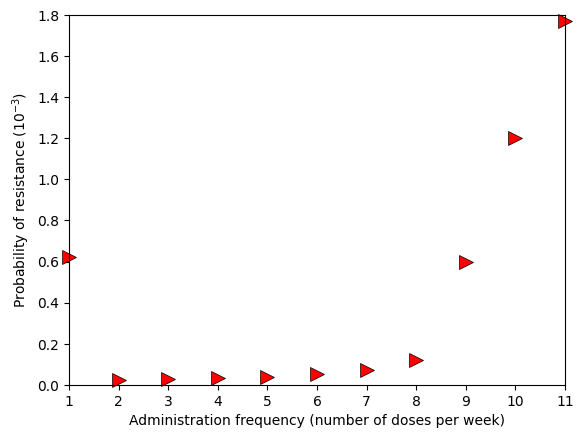

In [22]:
time = np.linspace(1, 11, 11)
y = [0.62, 0.025, 0.03, 0.035, 0.04, 0.05, 0.07, 0.12, 0.6, 1.2, 1.77]
plt.plot(time, y, '>', markersize = 10, c = 'red', markeredgecolor='black', 
         markeredgewidth=0.5, clip_on = False)
plt.xlim(1,11)
plt.ylim(0,1.8)

plt.xticks(np.linspace(1, 11, 11))

plt.ylabel(r'Probability of resistance ($10^{-3}$)')
plt.xlabel('Administration frequency (number of doses per week)')

plt.savefig('Figs/probs_6.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show

Extension: Fully resistant cells

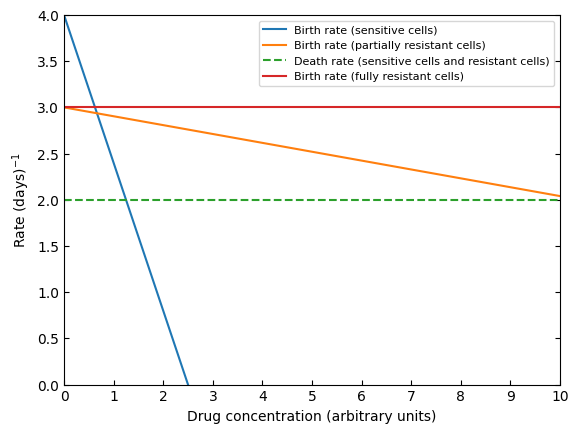

In [34]:
M0 = 1e6
u = 1e-8
f_r = np.ones(11) * 0.3
plt.plot(conc, lx * M0 * u * 1e3, label = 'Birth rate (sensitive cells)')
plt.plot(conc, ly * M0 * u * 1e3, label = 'Birth rate (partially resistant cells)')
plt.plot(conc, mx * M0 * u * 1e3, label = 'Death rate (sensitive cells and resistant cells)', linestyle = '--')
plt.plot(conc, f_r * M0 * u * 1e3, label = 'Birth rate (fully resistant cells)')
#plt.plot(conc, my * M0 * u * 1e3, label = 'Death rate (resistant cells)', linestyle = '--')

plt.xlim(0, 10)
plt.ylim(0, 4)

plt.xlabel('Drug concentration (arbitrary units)')
plt.ylabel(r'Rate (days)$^{-1}$')

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.legend(loc = 'upper right', fontsize = 8)

plt.gca().tick_params(right=True, direction='in')

plt.savefig('Figs/all_rates_6_full_resistance.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

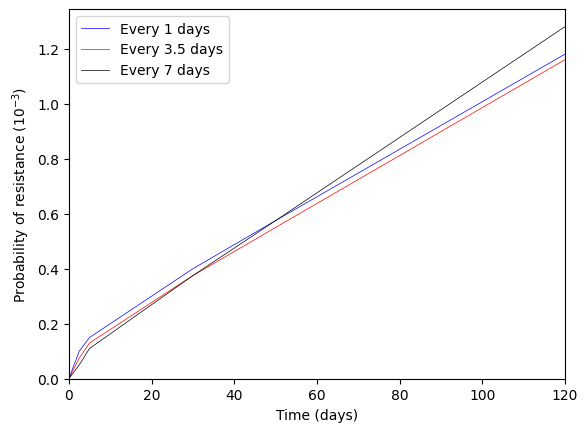

In [32]:
time = [0, 2.5, 5,30, 50, 120]

weekly = [0, 0.05, 0.11, 0.375, 0.575, 1.28] 
twice_weekly = [0, 0.075, 0.13, 0.375,0.55, 1.16] 
daily = [0, 0.1,  0.15, 0.4, 0.575, 1.18]
list_ = [daily, twice_weekly, weekly]
tau = [1, 3.5, 7]
colours = ['blue', 'red', 'black']
count = 0
#To maintain the AUC we need D_new = D_1 * tau_new/tau_1
#tau_1 = 1 so just 0.6 * tau_new
#see notes for derivation. Solve AUC = integral(C(t)) form o to inf
for x in list_:
    plt.plot(time, x, c = colours[count], label = f'Every {tau[count]} days', lw = 0.5)
    count += 1
plt.legend()
plt.xlim(0, T)
plt.ylim(0, None)

plt.xlabel('Time (days)')
plt.ylabel(r'Probability of resistance ($10^{-3}$)')

plt.savefig('Figs/probs_5.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

Discussion section. Very much arbitrary. Can't really tell what the parameters are until we get a working probability. 

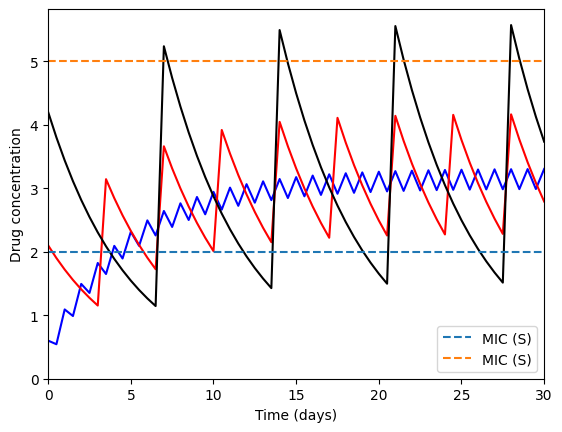

In [45]:
T = 30
time = np.linspace(0, T, (T*2)+1)
store_NLD = np.zeros(len(time))

sens_intersection = 2
resist_intersection = 5 

sens = np.ones(len(time)) * sens_intersection
res = np.ones(len(time)) * resist_intersection

D = 0.6
k = 0.2
tau = [1, 3.5, 7]
colours = ['blue', 'red', 'black']
#To maintain the AUC we need D_new = D_1 * tau_new/tau_1
#tau_1 = 1 so just 0.6 * tau_new
#see notes for derivation. Solve AUC = integral(C(t)) form o to inf
D = 0.6
dict = zip(tau, colours)
for t, col in dict:
    for i, g in enumerate(time):
        store_NLD[i] = get_concentration(g, (D*t), k, t, False)
    plt.plot(time, store_NLD, c = col)#, label = f'Every {t} days')
plt.plot(time, sens, '--', label = 'MIC (S)')
plt.plot(time, res, '--', label = 'MIC (S)')
plt.legend()
plt.xlim(0, T)
plt.ylim(0, None)

plt.xlabel('Time (days)')
plt.ylabel('Drug concentration')

#plt.savefig('Figs/discussion_conc.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()